In [5]:
# Time:  O(nlogn)
# Space: O(n)

start, end, height = 0, 1, 2
class Solution(object):
    # @param {integer[][]} buildings
    # @return {integer[][]}
    def getSkyline(self, buildings):
        intervals = self.ComputeSkylineInInterval(buildings, 0, len(buildings))

        res = []
        last_end = -1
        for interval in intervals:
            if last_end != -1 and last_end < interval[start]:
                res.append([last_end, 0])
            res.append([interval[start], interval[height]])
            last_end = interval[end]
        if last_end != -1:
            res.append([last_end, 0])

        return res

    # Divide and Conquer.
    def ComputeSkylineInInterval(self, buildings, left_endpoint, right_endpoint):
        if right_endpoint - left_endpoint <= 1:
            return buildings[left_endpoint:right_endpoint]
        mid = left_endpoint + ((right_endpoint - left_endpoint) / 2)
        left_skyline = self.ComputeSkylineInInterval(buildings, left_endpoint, mid)
        right_skyline = self.ComputeSkylineInInterval(buildings, mid, right_endpoint)
        return self.MergeSkylines(left_skyline, right_skyline)

    # Merge Sort.
    def MergeSkylines(self, left_skyline, right_skyline):
        i, j = 0, 0
        merged = []

        while i < len(left_skyline) and j < len(right_skyline):
            if left_skyline[i][end] < right_skyline[j][start]:
                merged.append(left_skyline[i])
                i += 1
            elif right_skyline[j][end] < left_skyline[i][start]:
                merged.append(right_skyline[j])
                j += 1
            elif left_skyline[i][start] <= right_skyline[j][start]:
                i, j = self.MergeIntersectSkylines(merged, left_skyline[i], i,\
                                                   right_skyline[j], j)
            else: # left_skyline[i][start] > right_skyline[j][start].
                j, i = self.MergeIntersectSkylines(merged, right_skyline[j], j, \
                                                   left_skyline[i], i)

        # Insert the remaining skylines.
        merged += left_skyline[i:]
        merged += right_skyline[j:]
        return merged

    # a[start] <= b[start]
    def MergeIntersectSkylines(self, merged, a, a_idx, b, b_idx):
        if a[end] <= b[end]:
            if a[height] > b[height]:   # |aaa|
                if b[end] != a[end]:    # |abb|b
                    b[start] = a[end]
                    merged.append(a)
                    a_idx += 1
                else:             # aaa
                    b_idx += 1    # abb
            elif a[height] == b[height]:  # abb
                b[start] = a[start]       # abb
                a_idx += 1
            else:  # a[height] < b[height].
                if a[start] != b[start]:                            #    bb
                    merged.append([a[start], b[start], a[height]])  # |a|bb
                a_idx += 1
        else:  # a[end] > b[end].
            if a[height] >= b[height]:  # aaaa
                b_idx += 1              # abba
            else:
                #    |bb|
                # |a||bb|a
                if a[start] != b[start]:
                    merged.append([a[start], b[start], a[height]])
                a[start] = b[end]
                merged.append(b)
                b_idx += 1
        return a_idx, b_idx
    
    

[[2, 10], [3, 15], [7, 12], [12, 0], [15, 10], [20, 8], [24, 0]]


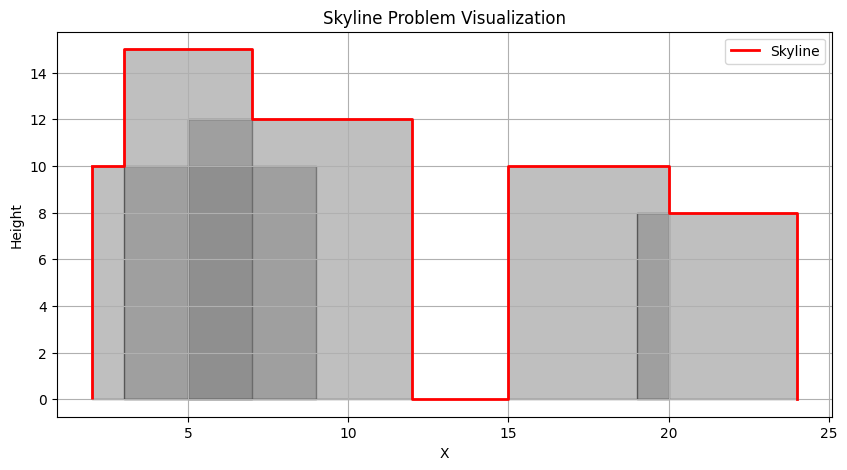

In [1]:
import matplotlib.pyplot as plt

start, end, height = 0, 1, 2

class Solution(object):
    # @param {integer[][]} buildings
    # @return {integer[][]}
    def getSkyline(self, buildings):
        # Convert tuples to lists so they can be modified
        buildings = [list(building) for building in buildings]

        intervals = self.ComputeSkylineInInterval(buildings, 0, len(buildings))

        res = []
        last_end = -1
        for interval in intervals:
            if last_end != -1 and last_end < interval[start]:
                res.append([last_end, 0])
            res.append([interval[start], interval[height]])
            last_end = interval[end]
        if last_end != -1:
            res.append([last_end, 0])

        return res

    # Divide and Conquer.
    def ComputeSkylineInInterval(self, buildings, left_endpoint, right_endpoint):
        if right_endpoint - left_endpoint <= 1:
            return [list(building) for building in buildings[left_endpoint:right_endpoint]]  # Convert tuples to lists
        mid = left_endpoint + ((right_endpoint - left_endpoint) // 2)
        left_skyline = self.ComputeSkylineInInterval(buildings, left_endpoint, mid)
        right_skyline = self.ComputeSkylineInInterval(buildings, mid, right_endpoint)
        return self.MergeSkylines(left_skyline, right_skyline)

    # Merge Sort.
    def MergeSkylines(self, left_skyline, right_skyline):
        i, j = 0, 0
        merged = []

        while i < len(left_skyline) and j < len(right_skyline):
            if left_skyline[i][end] < right_skyline[j][start]:
                merged.append(left_skyline[i])
                i += 1
            elif right_skyline[j][end] < left_skyline[i][start]:
                merged.append(right_skyline[j])
                j += 1
            elif left_skyline[i][start] <= right_skyline[j][start]:
                i, j = self.MergeIntersectSkylines(merged, left_skyline[i], i, right_skyline[j], j)
            else:  # left_skyline[i][start] > right_skyline[j][start].
                j, i = self.MergeIntersectSkylines(merged, right_skyline[j], j, left_skyline[i], i)

        # Insert the remaining skylines.
        merged += left_skyline[i:]
        merged += right_skyline[j:]
        return merged

    # a[start] <= b[start]
    def MergeIntersectSkylines(self, merged, a, a_idx, b, b_idx):
        if a[end] <= b[end]:
            if a[height] > b[height]:  # |aaa|
                if b[end] != a[end]:   # |abb|b
                    b[start] = a[end]
                    merged.append(a)
                    a_idx += 1
                else:  # aaa
                    b_idx += 1  # abb
            elif a[height] == b[height]:  # abb
                b[start] = a[start]  # abb
                a_idx += 1
            else:  # a[height] < b[height].
                if a[start] != b[start]:                            #    bb
                    merged.append([a[start], b[start], a[height]])  # |a|bb
                a_idx += 1
        else:  # a[end] > b[end].
            if a[height] >= b[height]:  # aaaa
                b_idx += 1  # abba
            else:
                #    |bb|
                # |a||bb|a
                if a[start] != b[start]:
                    merged.append([a[start], b[start], a[height]])
                a[start] = b[end]
                merged.append(b)
                b_idx += 1
        return a_idx, b_idx

    # Method to visualize the skyline
    def plot_skyline(self, buildings, skyline):
        fig, ax = plt.subplots(figsize=(10, 5))

        # Plot buildings as filled rectangles
        for b in buildings:
            x1, x2, h = b
            ax.fill_between([x1, x2], 0, h, color='gray', alpha=0.5, edgecolor='black')

        # Plot skyline
        x_vals, y_vals = zip(*skyline)
        ax.step(x_vals, y_vals, where='post', color='red', linewidth=2, label='Skyline')

        # Ensure the first vertical wall is drawn in red
        ax.vlines(x_vals[0], 0, y_vals[0], color='red', linewidth=2)

        ax.set_xlabel('X')
        ax.set_ylabel('Height')
        ax.set_title('Skyline Problem Visualization')
        ax.legend()
        plt.grid()
        plt.show()

# Example Usage
buildings = [(2, 9, 10), (3, 7, 15), (5, 12, 12), (15, 20, 10), (19, 24, 8)]

sol = Solution()
skyline = sol.getSkyline(buildings)

print(skyline)  # Expected Output: [[2, 10], [3, 15], [7, 10], [9, 0], [12, 0], [15, 10], [20, 8], [24, 0]]

sol.plot_skyline(buildings, skyline)
